# MAE-HAR SSL Ablation Visualization

Unified notebook for visualizing MAE pretraining ablation results:

- **Section A — Mask Ratio Ablation** (enc12 layer-probing across mask ratios 0.50 / 0.75 / 0.875 / 0.95, layers 1/3/6/9/12)
- **Section B — Mask Strategy Ablation** (enc6, mask_ratio=0.75, strategies random / freq / mixed / time)

Both sections share the same loading, grouping, and plotting utilities (defined once below) so the
two ablations are visualized consistently and any fix to the loader benefits both.

Edit `RESULTS_DIR` / `FIG_DIR` in the config cell to point at your actual results directory before running.

In [2]:
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# -- Paths --------------------------------------------------------------
# Point these at wherever your MAE-HAR result JSONs live.
RESULTS_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results")
FIG_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPLITS = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
SPLIT_LABELS = {
    "test_id": "ID (in-distribution)",
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env",
    "test_cross_user": "Cross-User",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

## Shared loading & grouping utilities

In [3]:
def load_matching_results(directory, filters, debug=False):
    """
    Recursively load all *.json result files under `directory` whose `args`
    dict matches every key/value in `filters`. A filter value of None means
    "no constraint on that key". Values are cast defensively (float/int)
    since some older training runs may have serialized args as strings.

    With debug=True, prints a [match]/[skip reason] line per candidate file --
    the fastest way to diagnose an empty result list.
    """
    results = []
    candidates = sorted(Path(directory).rglob("*.json"))
    if debug:
        print(f"[debug] found {len(candidates)} .json files under {directory} (recursive)")

    for fp in candidates:
        try:
            data = json.loads(fp.read_text())
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            if debug:
                print(f"[skip] {fp.name}: failed to parse ({e})")
            continue

        args = data.get("args")
        if args is None:
            if debug:
                print(f"[skip] {fp.name}: no args key")
            continue

        reasons = []
        for key, expected in filters.items():
            if expected is None:
                continue
            actual = args.get(key)
            if actual is None:
                reasons.append(f"{key} missing from args")
                continue
            try:
                if isinstance(expected, float):
                    if not np.isclose(float(actual), expected):
                        reasons.append(f"{key}={actual!r} != {expected}")
                elif isinstance(expected, int):
                    if int(actual) != expected:
                        reasons.append(f"{key}={actual!r} != {expected}")
                else:
                    if str(actual) != str(expected):
                        reasons.append(f"{key}={actual!r} != {expected!r}")
            except (TypeError, ValueError):
                reasons.append(f"{key}={actual!r} not comparable to {expected!r}")

        if reasons:
            if debug:
                print(f"[skip] {fp.name}: " + "; ".join(reasons))
            continue

        if debug:
            print(f"[match] {fp.name}")
        results.append(data)
    return results


def group_by(results, key_fn):
    """Group loaded results by an arbitrary key function, e.g.
    key_fn=lambda r: r['args']['mask_strategy']  or  key_fn=lambda r: r['args']['mask_ratio']
    """
    groups = defaultdict(list)
    for r in results:
        groups[key_fn(r)].append(r)
    return dict(groups)


def get_layers(result):
    first_ckpt = next(iter(result["evals"].values()))
    layers = list(first_ckpt.keys())
    layers.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return layers


def get_checkpoints(result):
    ckpts = list(result["evals"].keys())
    ckpts.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return ckpts

## Shared plotting utilities

In [15]:
def plot_loss_curve_by_group(groups, outdir, filename, title, colors=None, group_label_fmt="{k}"):
    """One loss curve per group key (mean +/- std across runs in that group)."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        epochs = np.array([pt["epoch"] for pt in runs[0]["loss_log"]])
        loss_matrix = np.array([[pt["loss"] for pt in r["loss_log"]] for r in runs])
        mean_loss = loss_matrix.mean(axis=0)
        std_loss = loss_matrix.std(axis=0)
        color = colors.get(key) if colors else None
        label = group_label_fmt.format(k=key) + f" (n={len(runs)})"
        ax.plot(epochs, mean_loss, label=label, color=color, linewidth=1.5)
        ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.15)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE Reconstruction Loss")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_final_accuracy_by_group(groups, outdir, filename, title, metric="lp_acc", layer=None,
                                  colors=None, group_label_fmt="{k}"):
    """Grouped bar chart: final-epoch metric per test split, one bar-group per key in `groups`."""
    keys = sorted(groups.keys(), key=str)
    x = np.arange(len(TEST_SPLITS))
    width = 0.8 / len(keys)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, key in enumerate(keys):
        runs = groups[key]
        target_layer = layer or get_layers(runs[0])[-1]
        means, stds = [], []
        for split in TEST_SPLITS:
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                vals.append(r["evals"][final_ckpt][target_layer][split][metric])
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        color = colors.get(key) if colors else None
        label = group_label_fmt.format(k=key) + f" (n={len(runs)})"
        ax.bar(x + i * width, means, width, yerr=stds, capsize=3, label=label, color=color)

    ax.set_xticks(x + width * (len(keys) - 1) / 2)
    ax.set_xticklabels([SPLIT_LABELS[s] for s in TEST_SPLITS])
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_summary_table_image(groups, outdir, filename, title, metric="lp_acc", layer=None,
                              group_label_fmt="{k}"):
    """Rendered table image: rows=group key (with n), columns=test split,
    cell text = 'mean +/- std'. Best value per column highlighted green, worst red.
    """
    keys = sorted(groups.keys(), key=str)
    mean_matrix = np.zeros((len(keys), len(TEST_SPLITS)))
    std_matrix = np.zeros((len(keys), len(TEST_SPLITS)))
    n_per_key = []

    for i, key in enumerate(keys):
        runs = groups[key]
        n_per_key.append(len(runs))
        target_layer = layer or get_layers(runs[0])[-1]
        for j, split in enumerate(TEST_SPLITS):
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                vals.append(r["evals"][final_ckpt][target_layer][split][metric])
            mean_matrix[i, j] = np.mean(vals)
            std_matrix[i, j] = np.std(vals)

    row_labels = [f"{group_label_fmt.format(k=k)} (n={n})" for k, n in zip(keys, n_per_key)]
    col_labels = [SPLIT_LABELS[s] for s in TEST_SPLITS]
    cell_text = [[f"{mean_matrix[i, j]:.4f} +/- {std_matrix[i, j]:.3f}" for j in range(len(TEST_SPLITS))]
                 for i in range(len(keys))]

    cell_colors = [["white"] * len(TEST_SPLITS) for _ in keys]
    for j in range(len(TEST_SPLITS)):
        col_vals = mean_matrix[:, j]
        cell_colors[int(np.argmax(col_vals))][j] = "#c8f0c8"   # best = light green
        cell_colors[int(np.argmin(col_vals))][j] = "#f5c6c6"   # worst = light red

    fig_height = 0.6 + 0.45 * len(keys)
    fig, ax = plt.subplots(figsize=(2.4 * len(TEST_SPLITS) + 2, fig_height))
    ax.axis("off")
    table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                      cellColours=cell_colors, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#dfe6f0")
    ax.set_title(title + "\n(green=best, red=worst per column)", fontsize=12, pad=20)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_layer_probing(result, outdir, filename, checkpoint=None, title_suffix=""):
    """Layer-wise KNN vs LP accuracy at a given checkpoint, one subplot per test split."""
    ckpts = get_checkpoints(result)
    checkpoint = checkpoint or ckpts[-1]
    layers = get_layers(result)
    layer_ids = [int(re.search(r"\d+", l).group()) for l in layers]

    fig, axes = plt.subplots(1, len(TEST_SPLITS), figsize=(5 * len(TEST_SPLITS), 4.5), sharey=True)
    for ax, split in zip(axes, TEST_SPLITS):
        knn_acc = [result["evals"][checkpoint][l][split]["knn_acc"] for l in layers]
        lp_acc = [result["evals"][checkpoint][l][split]["lp_acc"] for l in layers]
        ax.plot(layer_ids, knn_acc, "o-", label="KNN acc", color="tab:blue")
        ax.plot(layer_ids, lp_acc, "s-", label="LP acc", color="tab:orange")
        ax.set_title(SPLIT_LABELS[split])
        ax.set_xlabel("Encoder Layer")
        ax.set_xticks(layer_ids)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(fontsize=9)
    fig.suptitle(f"Layer-wise Probing @ {checkpoint}{title_suffix}")
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_epoch_layer_heatmap(result, outdir, filename, split="test_cross_device", metric="lp_acc", title_suffix=""):
    """Epoch x layer heatmap for one experiment / test split / metric --
    useful for seeing whether LP saturation happens at the same epoch across layer depths."""
    ckpts = get_checkpoints(result)
    layers = get_layers(result)
    layer_ids = [int(re.search(r"\d+", l).group()) for l in layers]
    epoch_ids = [int(re.search(r"\d+", c).group()) for c in ckpts]

    matrix = np.zeros((len(layers), len(ckpts)))
    for i, l in enumerate(layers):
        for j, c in enumerate(ckpts):
            matrix[i, j] = result["evals"][c][l][split][metric]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.imshow(matrix, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(ckpts)))
    ax.set_xticklabels(epoch_ids)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(layer_ids)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Encoder Layer")
    ax.set_title(f"{SPLIT_LABELS[split]} - {metric}{title_suffix}")
    for i in range(len(layers)):
        for j in range(len(ckpts)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                     color="white" if matrix[i, j] < matrix.max() * 0.7 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label=metric)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def print_summary_table(groups, layer=None, metric="lp_acc", group_label_fmt="{k}"):
    print(f"\n=== Summary: {metric} (mean +/- std across runs) ===")
    header = f"{'group':<14}" + "".join(f"{SPLIT_LABELS[s]:>20}" for s in TEST_SPLITS)
    print(header)
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        target_layer = layer or get_layers(runs[0])[-1]
        row = f"{group_label_fmt.format(k=key):<14}"
        for split in TEST_SPLITS:
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                vals.append(r["evals"][final_ckpt][target_layer][split][metric])
            row += f"{np.mean(vals):>14.4f} +/- {np.std(vals):<4.3f}"
        print(row)

## Section A — Mask Ratio Ablation (enc12 layer-probing)

Filters on `mask_strategy="random"`, `encoder_depth=12`, `patch_h=29`, `patch_w=25`, and groups by
`mask_ratio`. This is the currently-running enc12 layer-probing experiment (mask ratios x seeds x
eval_layers 1/3/6/9/12) — some (ratio, seed) combos may still be missing if that job hasn't finished yet,
which is expected and will just show up as a smaller `n` per ratio.

In [5]:
RATIO_FILTERS = {
    "mask_strategy": "random",
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False  # flip to True if 0 files match and you need to see why, per file

ratio_results = load_matching_results(RESULTS_DIR, RATIO_FILTERS, debug=DEBUG)
if not ratio_results:
    print("No mask-ratio-ablation (enc12) files matched. Set DEBUG=True above and re-run this cell.")
    ratio_groups = {}
else:
    ratio_groups = group_by(ratio_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(ratio_results)} files across {len(ratio_groups)} mask ratios: "
          f"{ {k: len(v) for k, v in ratio_groups.items()} }")

RATIO_COLORS = {0.5: "#0891B2", 0.75: "#7C3AED", 0.875: "#D97706", 0.95: "#DC2626"}

Found 5 files across 3 mask ratios: {0.5: 2, 0.75: 2, 0.875: 1}


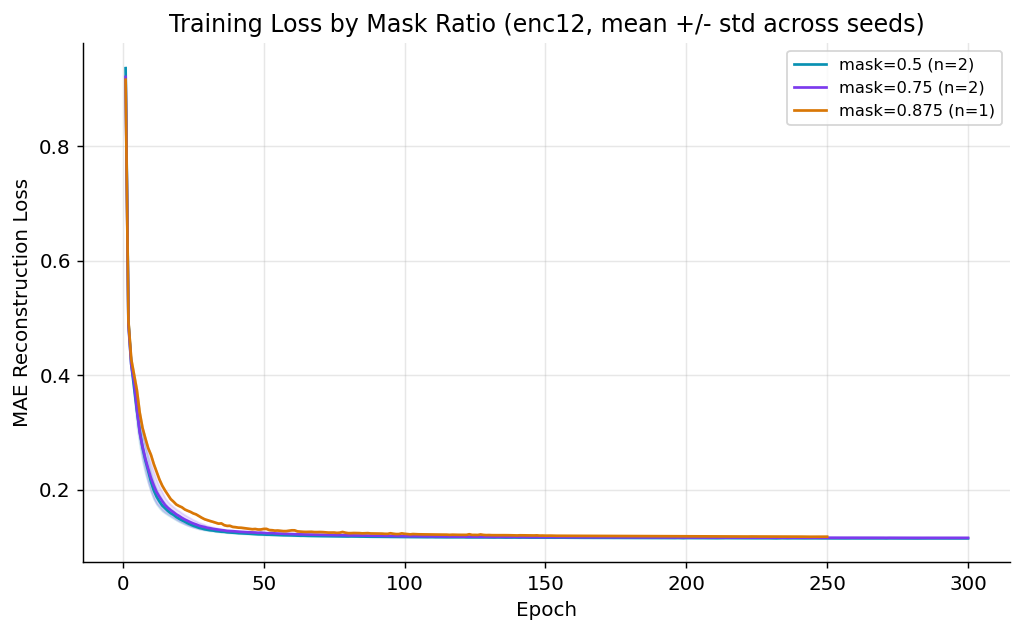

In [6]:
if ratio_groups:
    plot_loss_curve_by_group(
        ratio_groups, FIG_DIR, "ratio_loss_curve.png",
        title="Training Loss by Mask Ratio (enc12, mean +/- std across seeds)",
        colors=RATIO_COLORS, group_label_fmt="mask={k}",
    )

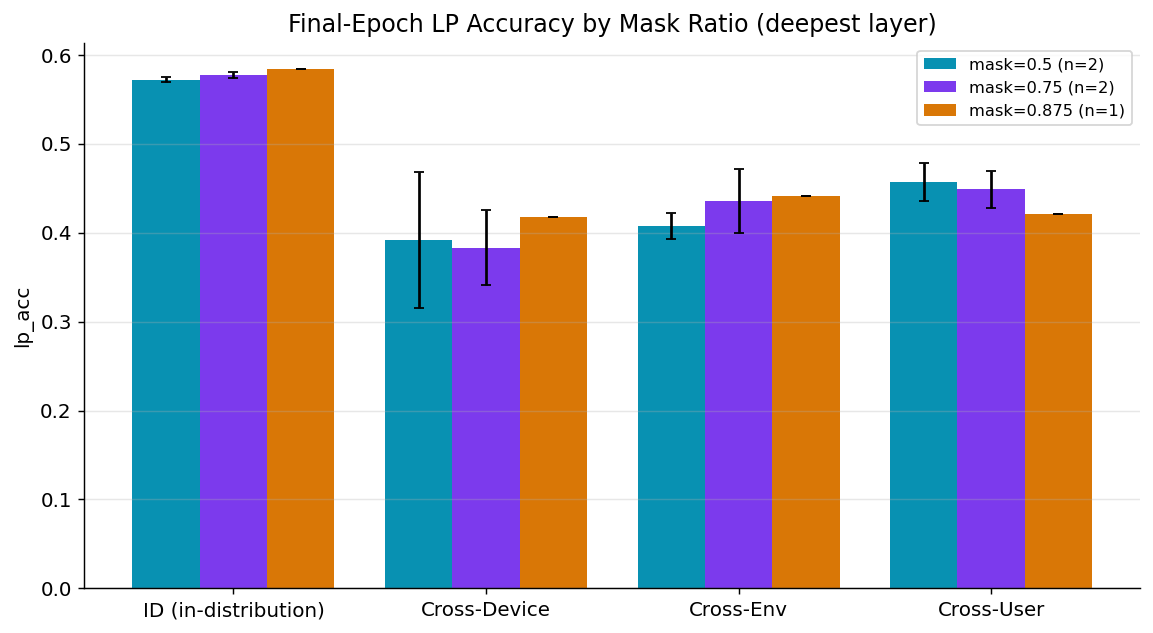

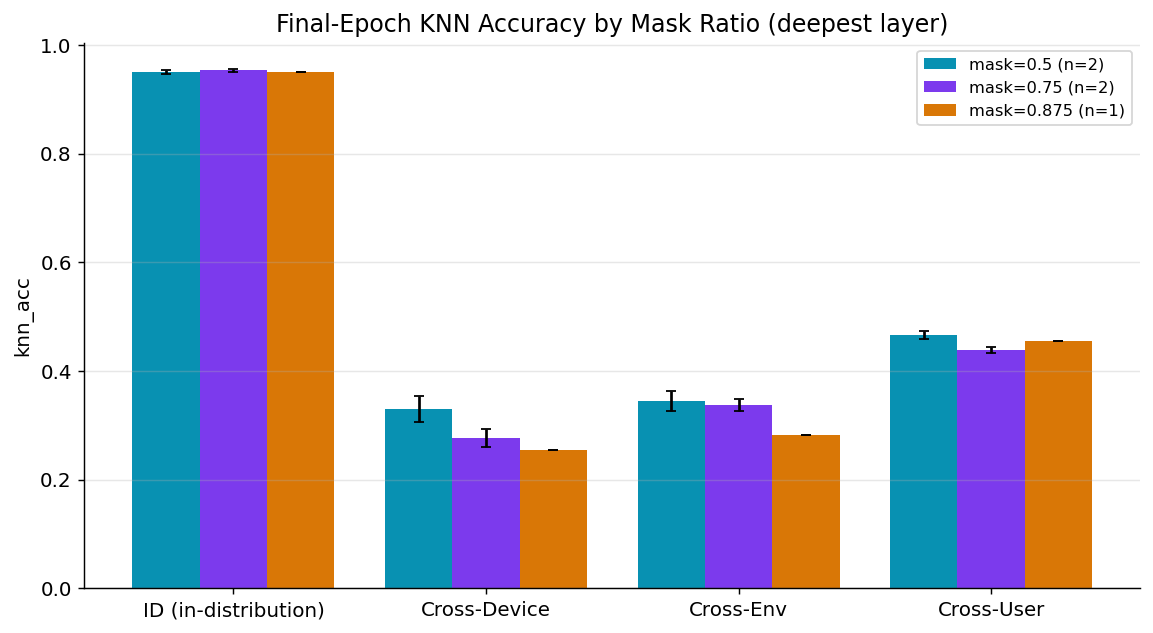

In [7]:
if ratio_groups:
    plot_final_accuracy_by_group(
        ratio_groups, FIG_DIR, "ratio_bar_lp_acc.png",
        title="Final-Epoch LP Accuracy by Mask Ratio (deepest layer)",
        metric="lp_acc", colors=RATIO_COLORS, group_label_fmt="mask={k}",
    )
    plot_final_accuracy_by_group(
        ratio_groups, FIG_DIR, "ratio_bar_knn_acc.png",
        title="Final-Epoch KNN Accuracy by Mask Ratio (deepest layer)",
        metric="knn_acc", colors=RATIO_COLORS, group_label_fmt="mask={k}",
    )

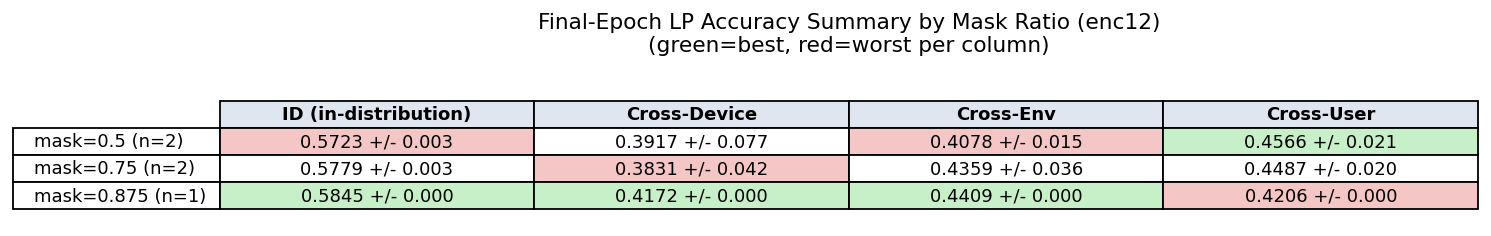


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.5723 +/- 0.003        0.3917 +/- 0.077        0.4078 +/- 0.015        0.4566 +/- 0.021
mask=0.75             0.5779 +/- 0.003        0.3831 +/- 0.042        0.4359 +/- 0.036        0.4487 +/- 0.020
mask=0.875            0.5845 +/- 0.000        0.4172 +/- 0.000        0.4409 +/- 0.000        0.4206 +/- 0.000


In [8]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_acc.png",
        title="Final-Epoch LP Accuracy Summary by Mask Ratio (enc12)",
        metric="lp_acc", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_acc", group_label_fmt="mask={k}")

**Per-ratio layer-wise probing.** For each mask ratio, plots KNN vs LP accuracy across encoder
layers 1/3/6/9/12 at the final checkpoint, using the first available seed as representative.

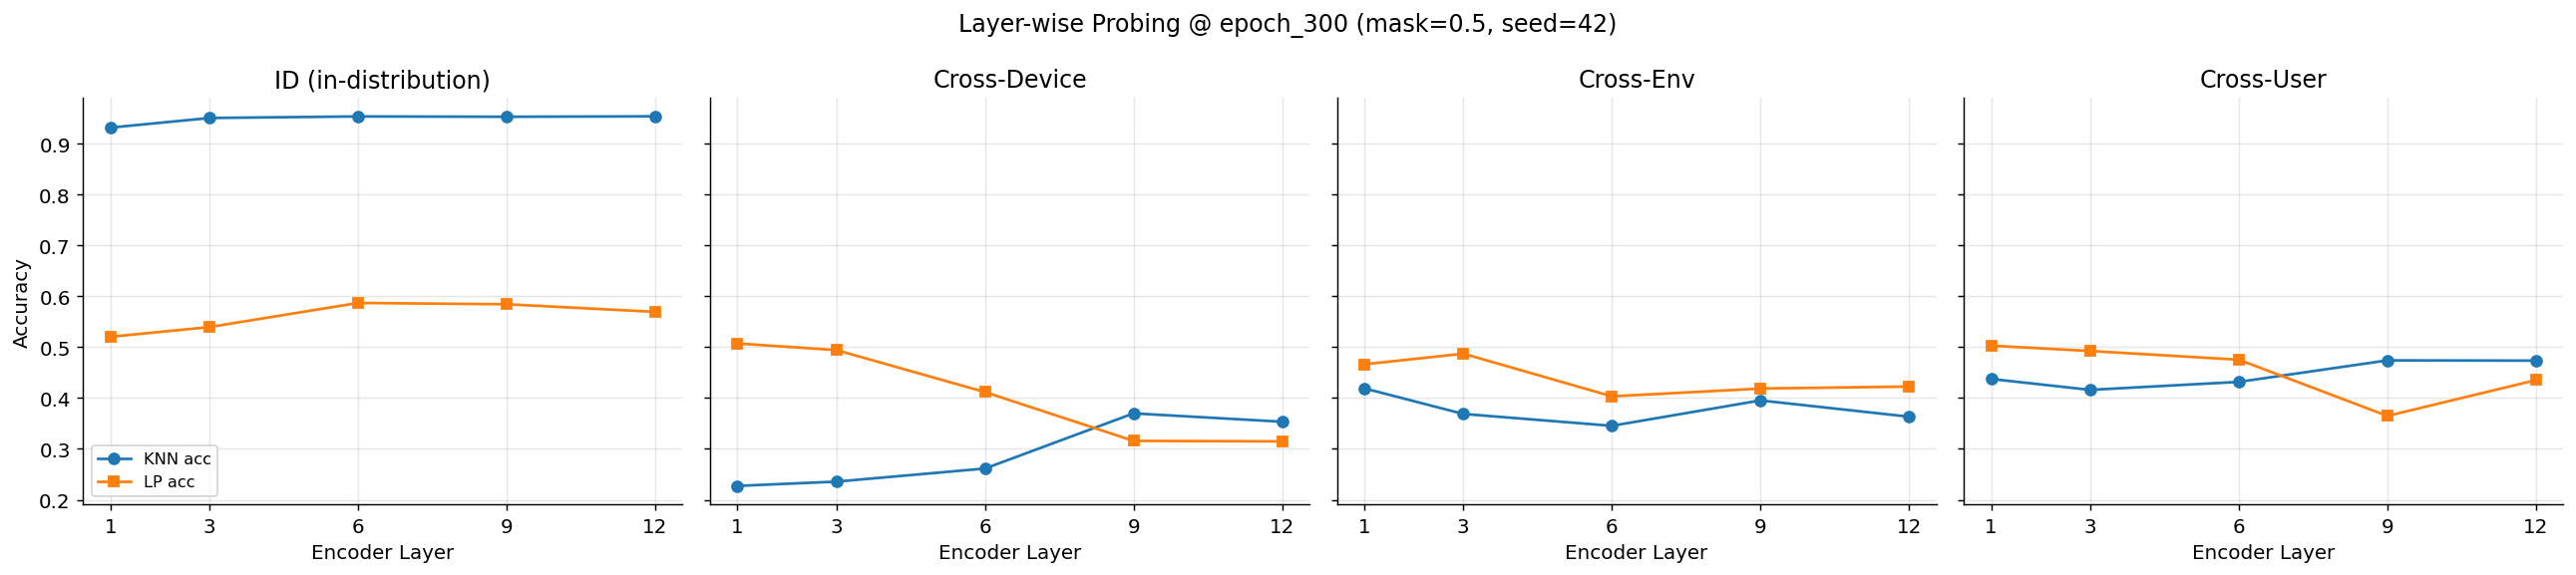

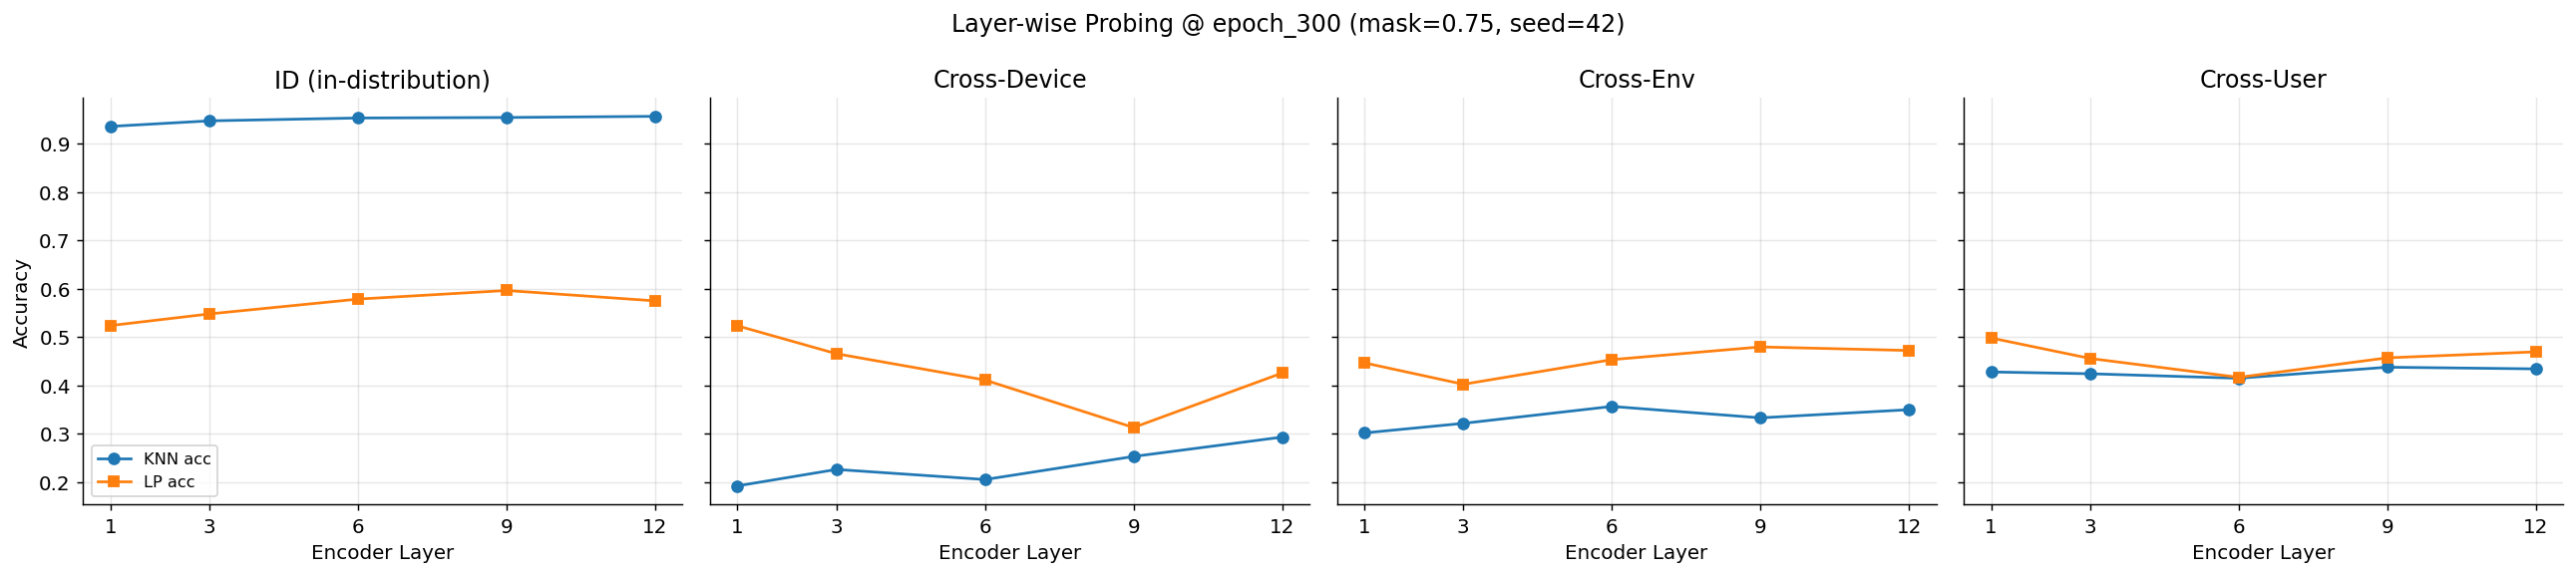

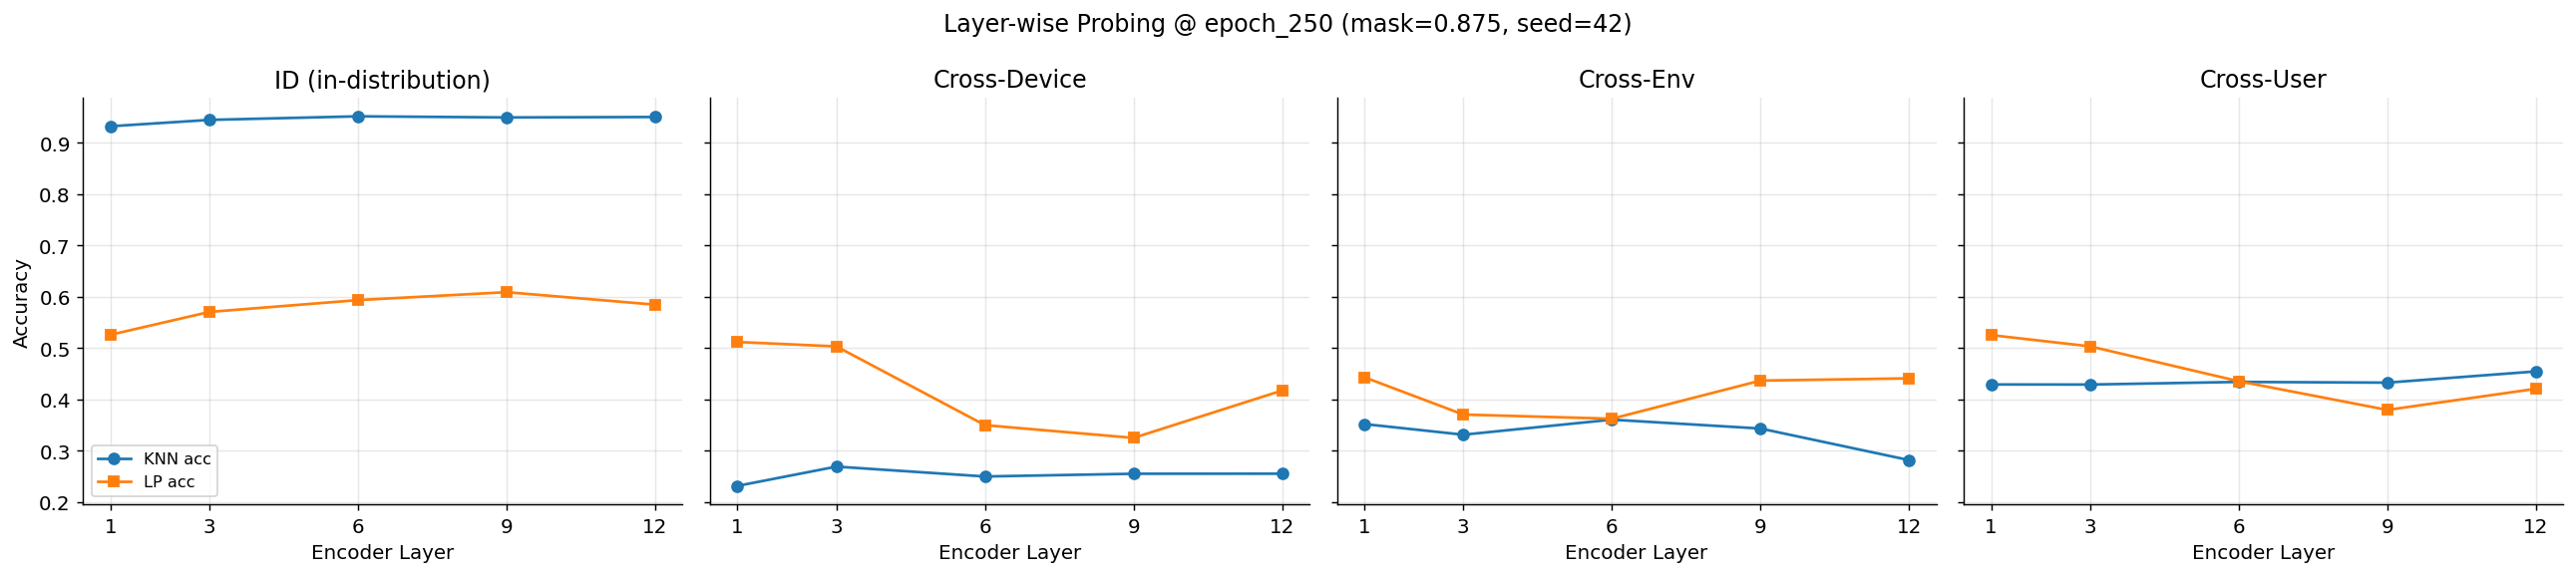

In [9]:
if ratio_groups:
    for ratio, runs in sorted(ratio_groups.items()):
        rep = runs[0]  # representative run (first available seed)
        plot_layer_probing(
            rep, FIG_DIR, f"ratio_layer_probing_mask{ratio}.png",
            title_suffix=f" (mask={ratio}, seed={rep['args'].get('seed')})",
        )

**Epoch x layer heatmap** (mask_ratio=0.75, cross_device split) — shows whether LP saturation
happens at the same training epoch across layer depths, or whether deeper layers need longer to converge.

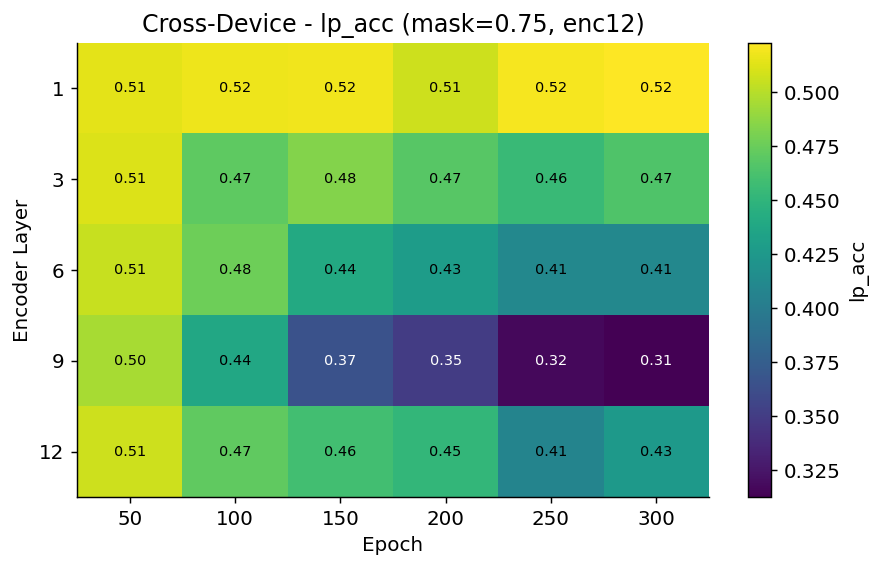

In [10]:
if 0.75 in ratio_groups:
    plot_epoch_layer_heatmap(
        ratio_groups[0.75][0], FIG_DIR, "ratio_heatmap_mask0.75_cross_device.png",
        split="test_cross_device", metric="lp_acc",
        title_suffix=" (mask=0.75, enc12)",
    )
else:
    print("mask_ratio=0.75 not found in ratio_groups -- skipping heatmap.")

## Section B — Mask Strategy Ablation (enc6, mask_ratio=0.75)

Filters on `mask_ratio=0.75`, `encoder_depth=6`, `patch_h=29`, `patch_w=25`, and groups by
`mask_strategy` (random / freq / mixed / time).

In [11]:
STRATEGY_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "patch_h": 29,
    "patch_w": 25,
}

strategy_results = load_matching_results(RESULTS_DIR, STRATEGY_FILTERS, debug=DEBUG)
if not strategy_results:
    print("No mask-strategy-ablation (enc6, mask=0.75) files matched. Set DEBUG=True above and re-run.")
    strategy_groups = {}
else:
    strategy_groups = group_by(strategy_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(strategy_results)} files across {len(strategy_groups)} strategies: "
          f"{ {k: len(v) for k, v in strategy_groups.items()} }")

STRATEGY_COLORS = {"random": "tab:blue", "freq": "tab:green", "mixed": "tab:orange", "time": "tab:red"}

Found 10 files across 5 strategies: {'2d': 1, 'freq': 2, 'mixed': 2, 'random': 3, 'time': 2}


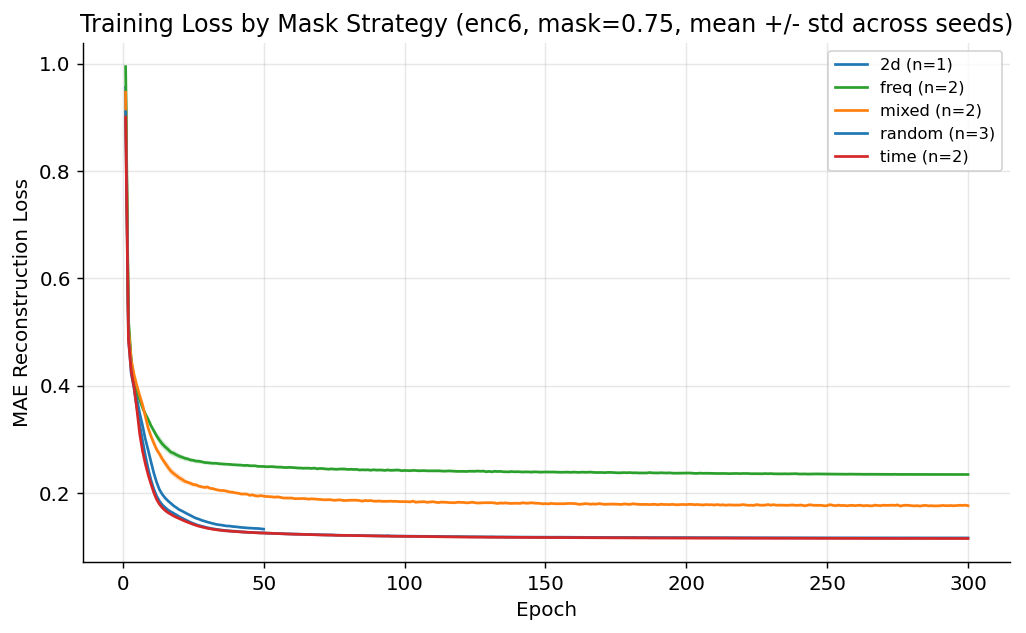

In [12]:
if strategy_groups:
    plot_loss_curve_by_group(
        strategy_groups, FIG_DIR, "strategy_loss_curve.png",
        title="Training Loss by Mask Strategy (enc6, mask=0.75, mean +/- std across seeds)",
        colors=STRATEGY_COLORS,
    )

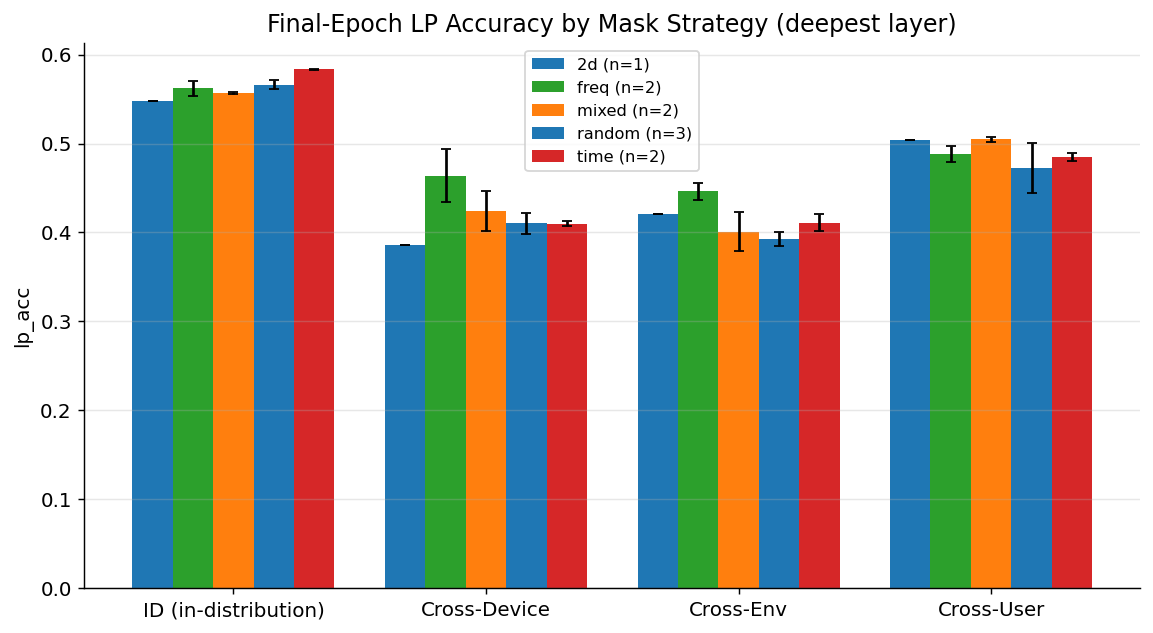

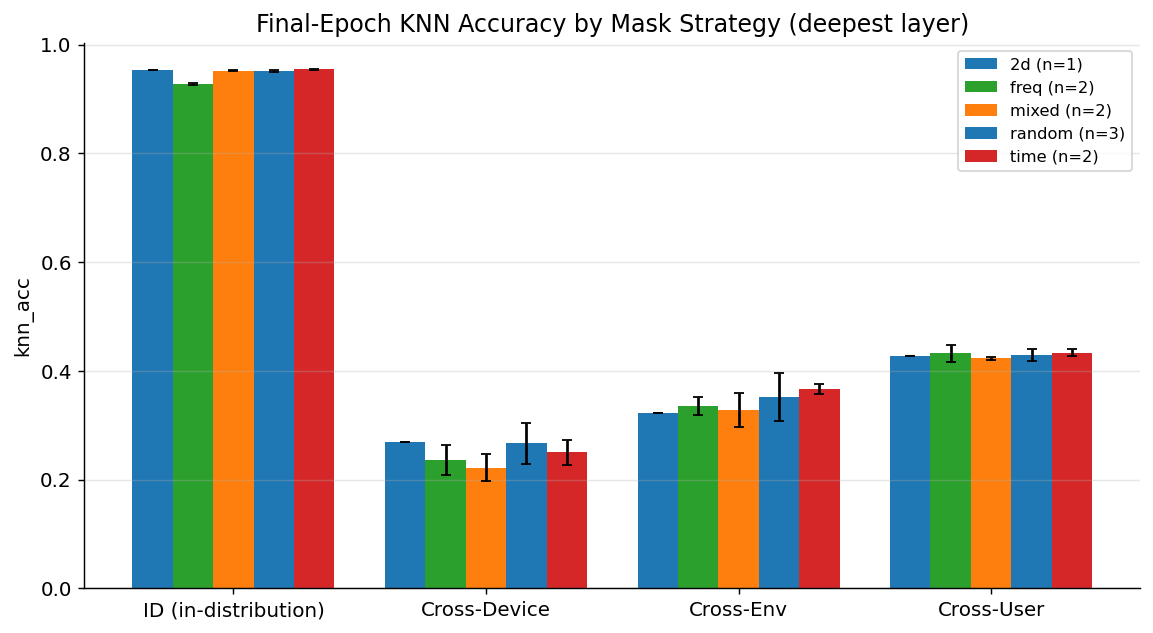

In [13]:
if strategy_groups:
    plot_final_accuracy_by_group(
        strategy_groups, FIG_DIR, "strategy_bar_lp_acc.png",
        title="Final-Epoch LP Accuracy by Mask Strategy (deepest layer)",
        metric="lp_acc", colors=STRATEGY_COLORS,
    )
    plot_final_accuracy_by_group(
        strategy_groups, FIG_DIR, "strategy_bar_knn_acc.png",
        title="Final-Epoch KNN Accuracy by Mask Strategy (deepest layer)",
        metric="knn_acc", colors=STRATEGY_COLORS,
    )

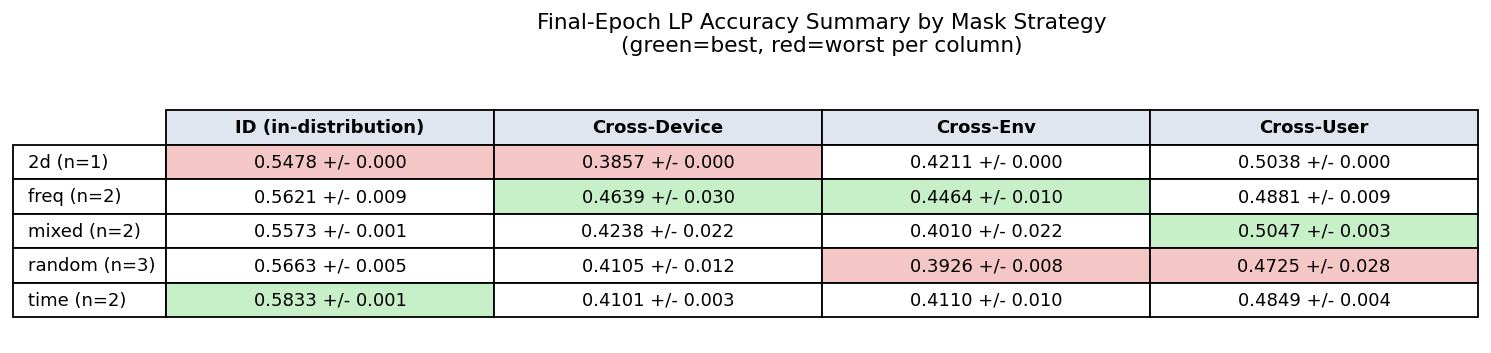

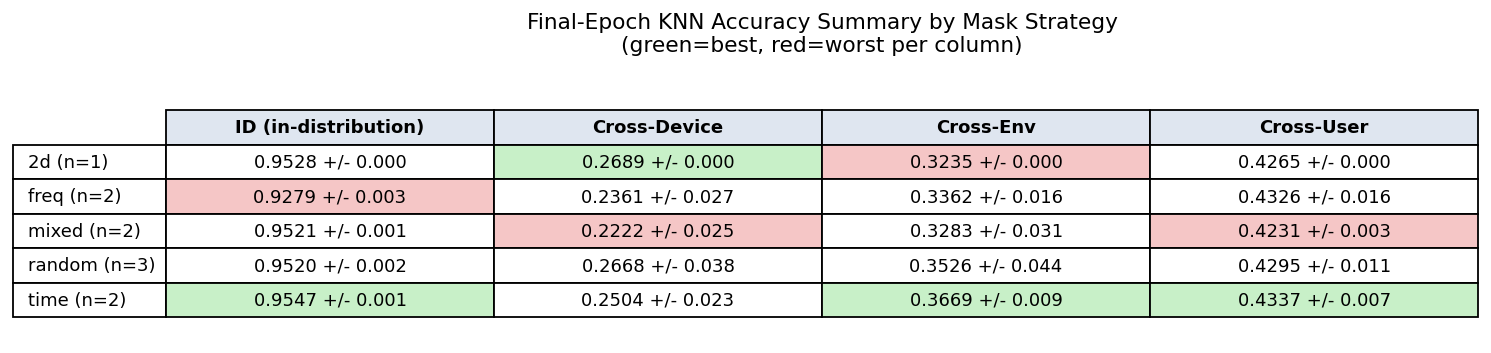


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5478 +/- 0.000        0.3857 +/- 0.000        0.4211 +/- 0.000        0.5038 +/- 0.000
freq                  0.5621 +/- 0.009        0.4639 +/- 0.030        0.4464 +/- 0.010        0.4881 +/- 0.009
mixed                 0.5573 +/- 0.001        0.4238 +/- 0.022        0.4010 +/- 0.022        0.5047 +/- 0.003
random                0.5663 +/- 0.005        0.4105 +/- 0.012        0.3926 +/- 0.008        0.4725 +/- 0.028
time                  0.5833 +/- 0.001        0.4101 +/- 0.003        0.4110 +/- 0.010        0.4849 +/- 0.004

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.9528 +/- 0.000        0.2689 +/- 0.000        0.3235 +/- 0.000        0.4265 +/- 0.000
freq                  0.9279 +/- 0.003 

In [14]:
if strategy_groups:
    plot_summary_table_image(
        strategy_groups, FIG_DIR, "strategy_table_lp_acc.png",
        title="Final-Epoch LP Accuracy Summary by Mask Strategy",
        metric="lp_acc",
    )
    plot_summary_table_image(
        strategy_groups, FIG_DIR, "strategy_table_knn_acc.png",
        title="Final-Epoch KNN Accuracy Summary by Mask Strategy",
        metric="knn_acc",
    )
    print_summary_table(strategy_groups, metric="lp_acc")
    print_summary_table(strategy_groups, metric="knn_acc")

## Notes / caveats

- **Sample size (n) matters.** Every bar chart / table shows `n` per group in the legend or row
  label. If a group shows `n=1` where you expect `n=2` (missing seed), or `n=3` where you expect
  `n=2` (a stray unseeded run got picked up by the filter), treat that group's numbers as
  provisional -- re-check `RATIO_FILTERS` / `STRATEGY_FILTERS` and the underlying files before
  drawing conclusions.
- **`DEBUG=True`** in either config cell prints a per-file `[match]` / `[skip: reason]` line, which
  is the fastest way to find out why a file was excluded (wrong `mask_ratio`, missing `patch_h`,
  wrong `encoder_depth`, etc.).
- The **enc12 layer-probing job (Section A)** may still be running -- ratios/seeds with fewer
  runs than expected likely just haven't finished yet, not necessarily a data problem.